In [2]:
# Installing Cudnn
!apt-cache policy c

# Install latest version
!apt install --allow-change-held-packages libcudnn8

# Export env variables
!export PATH=/usr/local/cuda-11.4/bin${PATH:+:${PATH}}
!export LD_LIBRARY_PATH=/usr/local/cuda-11.4/lib64:$LD_LIBRARY_PATH
!export LD_LIBRARY_PATH=/usr/local/cuda-11.4/include:$LD_LIBRARY_PATH
!export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/usr/local/cuda/extras/CUPTI/lib64

N: Unable to locate package c
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  libcudnn8
0 upgraded, 1 newly installed, 0 to remove and 29 not upgraded.
Need to get 444 MB of archives.
After this operation, 1,099 MB of additional disk space will be used.
Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  libcudnn8 8.9.7.29-1+cuda12.2 [444 MB]
Fetched 444 MB in 6s (78.6 MB/s)
Selecting previously unselected package libcudnn8.
(Reading database ... 124947 files and directories currently installed.)
Preparing to unpack .../libcudnn8_8.9.7.29-1+cuda12.2_amd64.deb ...
Unpacking libcudnn8 (8.9.7.29-1+cuda12.2) ...
Setting up libcudnn8 (8.9.7.29-1+cuda12.2) ...


In [3]:
import os, glob, time, random, pickle, cv2, shutil, gdown, re
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn import metrics

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses, callbacks
from tensorflow.keras import backend as K
import tensorboard
from tensorflow.keras.saving import register_keras_serializable
%matplotlib inline

In [4]:
#original Link
# https://drive.google.com/file/d/162oRpsX7JVSX2jjDLYvxrkqsVa_3CBIG/view?usp=sharing

# Global Variables
FILE_ID = "162oRpsX7JVSX2jjDLYvxrkqsVa_3CBIG"
regexStr = r'H-S-\d+-(G|F)-'
LangugeProcessing = "Hindi"
tf.keras.utils.set_random_seed(200)
height, width = 224, 224
BATCH_SIZE=4
channels = 3

In [5]:
# Utility Function

# function to download the dataset from the url
def download_dataset_from_url(url, file_path):
    try:
        # using gdown to download the data set from url id
        gdown.download(url, file_path, quiet=False)
        print(f"Successfully downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading file: {e}")

# function to unzip the file
def unzip_file_shutil(zip_path, extract_path):
    try:
        os.makedirs(extract_path, exist_ok=True)
        shutil.unpack_archive(zip_path, extract_path)
        print(f"Successfully extracted to {extract_path}")
    except Exception as e:
        print(f"Error extracting file: {e}")

def deleteLogs(log_path=""):

    if not log_path:
        log_path = os.path.join(os.getcwd(), "logs")
    try:
        shutil.rmtree(log_path)
        print(f"Deleted logs from {log_path}")
    except Exception as e:
        print(f"Error deleting logs: {e}")

def generate_logs_Folder(logfolderName="", usrTimestamp=True, clear_folder=False):
    currentPath = os.getcwd()

    # clear existing eventLogs if clear_folder is True
    if clear_folder:
        deleteLogs(os.path.join(currentPath, "logs"))

    if not os.path.exists(os.path.join(currentPath, "logs")):
        os.mkdir("logs")

    if logfolderName:
        if usrTimestamp:
            logfolderName = logfolderName + "_" + time.strftime("%Y%m%d-%H%M%S")
        else:
            logfolderName = logfolderName
        logName = os.path.join(currentPath, "logs", logfolderName)
        if not os.path.exists(logName):
            os.mkdir(logName)
    else:
        logName = os.path.join(currentPath, "logs")

    return logName

def generate_logs_Name(fileName, logFormat=".log", clear_folder=False):
    folderName = generate_logs_Folder(fileName, clear_folder=clear_folder)
    fileName = fileName + "_" + time.strftime("%Y%m%d-%H%M%S") + logFormat
    return os.path.join(folderName, fileName)

def download_and_prep_dataset(FILE_ID, folderName=""):
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    currentPath = os.getcwd()
    print("CWD: ", currentPath)
    dataSet_path = os.path.abspath(os.path.join(currentPath, "dataSet/BHSignature260.zip"))
    extractPath = os.path.abspath(os.path.join(currentPath, "unzipLoc/"))

    # create directory if not exists
    if not os.path.exists(os.path.abspath(os.path.join(currentPath, "dataSet/"))):
        os.mkdir(os.path.abspath(os.path.join(currentPath, "dataSet/")))

    if not os.path.exists(extractPath):
        os.mkdir(extractPath)

    # download the dataset
    if not os.path.exists(dataSet_path):
        download_dataset_from_url(url=url, file_path=dataSet_path)

    # unzip the dataset
    if os.listdir(extractPath) == []:
        unzip_file_shutil(zip_path=dataSet_path, extract_path=extractPath)

    # Load the dataset
    data_path = os.path.join(extractPath, "BHSig260")
    return data_path

In [6]:
## image Pair Loading

def check_image_status(fileName):
    match = re.search(regexStr, fileName)
    if match:
        return "Genuine" if match.group(1) == "G" else "Forged"
    return "Invalid"

def load_mapping_file(filePath):
    df = pd.read_csv(filePath, sep=" ", header=None, names=["image1", "image2", "issimilar"])
    return df

def load_and_preprocess_image(image_path, basePath, image_size=(224, 224)):
    height, width = image_size

    # Open the image with PIL
    fullImagePath = os.path.join(basePath, image_path)
    img = Image.open(fullImagePath)

    # Convert to RGB if needed
    if img.mode != 'RGB':
        img = img.convert('RGB')

    # Resize
    img = img.resize((width, height), Image.Resampling.BILINEAR)

    # Convert to numpy array and normalize
    img_array = np.array(img) / 255.0
    return img_array.astype(np.float32)

def generator(mapping_df, basePath, image_size):
    for _, row in mapping_df.iterrows():
        try:
            img1 = load_and_preprocess_image(image_path=row['image1'], basePath=basePath, image_size=image_size)
            img2 = load_and_preprocess_image(image_path=row['image2'], basePath=basePath, image_size=image_size)
            label = float(row['issimilar'])
            yield (img1, img2), label
        except Exception as e:
            print(f"Error loading images: {str(e)}")
            print(f"Image1 path: {row['image1']}")
            print(f"Image2 path: {row['image2']}")
            continue

def create_datasets_from_dataframe(dataframe, image_size=(224, 224), batch_size=32, basePath=""):
    height, width = image_size

    # Create dataset from generator
    output_types = ((tf.float32, tf.float32), tf.float32)
    output_shapes = ((tf.TensorShape([height, width, 3]), tf.TensorShape([height, width, 3])), tf.TensorShape([]))

    dataset = tf.data.Dataset.from_generator(
        lambda: generator(dataframe, basePath=basePath, image_size=image_size),
        output_types=output_types,
        output_shapes=output_shapes
    )

    # Batch and prefetch
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

def visualize_batch(dataset, num_examples=3):
    # Get a batch from the dataset
    for (img1_batch, img2_batch), labels_batch in dataset.take(1):
        plt.figure(figsize=(15, 3*min(num_examples, len(labels_batch))))

        for i in range(min(num_examples, len(labels_batch))):
            img1 = img1_batch[i].numpy()
            img2 = img2_batch[i].numpy()
            label = labels_batch[i].numpy()

            plt.subplot(min(num_examples, len(labels_batch)), 2, i*2 + 1)
            plt.imshow(img1)
            plt.title(f"Image 1")
            plt.axis('off')

            plt.subplot(min(num_examples, len(labels_batch)), 2, i*2 + 2)
            plt.imshow(img2)
            plt.title(f"Image 2 (Similar: {bool(label)})")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

In [7]:
dl_ext_data_path = download_and_prep_dataset(FILE_ID=FILE_ID)

languageDataSet = os.path.join(dl_ext_data_path, LangugeProcessing)
pathExist = os.path.exists(languageDataSet)
print(f"{languageDataSet}: Exists: {pathExist}")

image_1_2_mapping = load_mapping_file("/content/unzipLoc/BHSig260/Hindi/Hindi_pairs.txt")
trainVal_df, test_df = train_test_split(image_1_2_mapping, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(trainVal_df, test_size=0.15, random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

train_ds = create_datasets_from_dataframe(dataframe=train_df, basePath=languageDataSet)
Val_ds = create_datasets_from_dataframe(dataframe=val_df, basePath=languageDataSet)
test_ds = create_datasets_from_dataframe(dataframe=test_df, basePath=languageDataSet)

CWD:  /content


Downloading...
From (original): https://drive.google.com/uc?id=162oRpsX7JVSX2jjDLYvxrkqsVa_3CBIG
From (redirected): https://drive.google.com/uc?id=162oRpsX7JVSX2jjDLYvxrkqsVa_3CBIG&confirm=t&uuid=848be65a-7f3d-44d7-89b2-d9283ddf93ea
To: /content/dataSet/BHSignature260.zip
100%|██████████| 48.5M/48.5M [00:02<00:00, 20.8MB/s]


Successfully downloaded to /content/dataSet/BHSignature260.zip
Successfully extracted to /content/unzipLoc
/content/unzipLoc/BHSig260/Hindi: Exists: True
Train: 6476, Val: 1143, Test: 1345


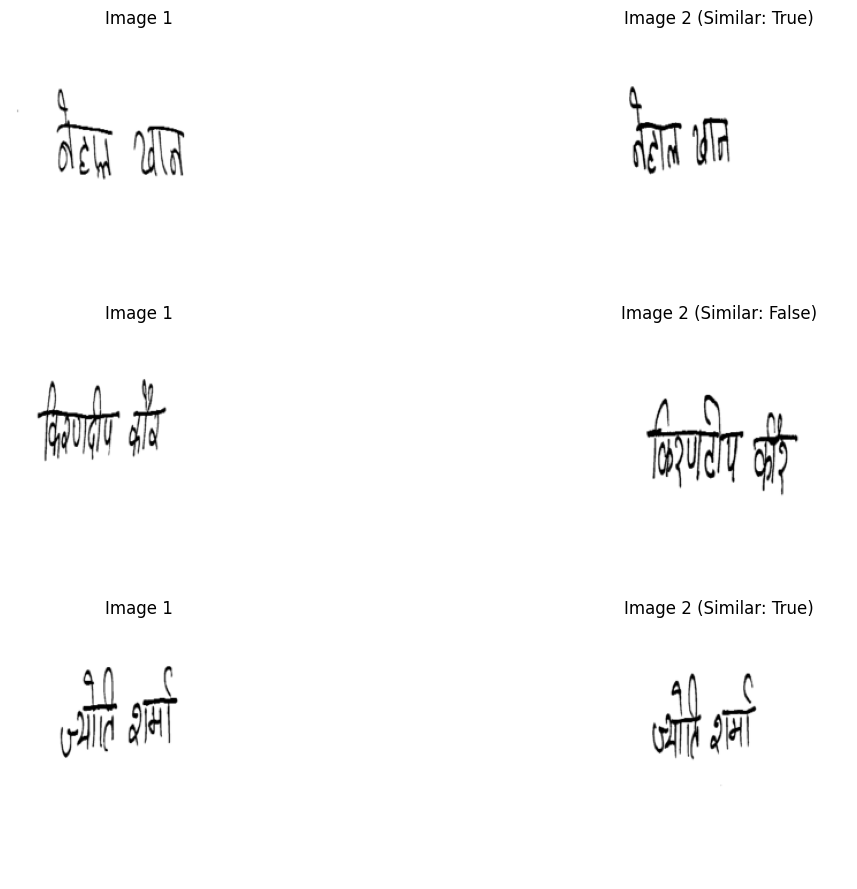

In [8]:
visualize_batch(train_ds, num_examples=3)

In [9]:
## create a siamese model

##helper function
@register_keras_serializable()
def euclidean_distance(vects):
    x, y = vects
    sum_square = K.sum(K.square(x - y), axis=1, keepdims=True)
    return K.sqrt(K.maximum(sum_square, K.epsilon()))

def embeddingModel():
    backBone = keras.applications.ResNet101V2(include_top=False, weights='imagenet', input_shape=(height, width, channels))
    backBone.trainable = False

    gapPool = keras.layers.GlobalAveragePooling2D()(backBone.output)
    dense1 = keras.layers.Dense(256, activation='relu')(gapPool)
    outputLayer = keras.layers.Dense(128, activation='relu')(dense1)

    return keras.Model(backBone.input, outputLayer)

def create_siameseModel():
    embedding = embeddingModel()

    imp1 = keras.Input(shape=(height, width, channels))
    imp2 = keras.Input(shape=(height, width, channels))
    embedding_1 = embedding(imp1)
    embedding_2 = embedding(imp2)

    distance = keras.layers.Lambda(euclidean_distance)([embedding_1, embedding_2])
    model = keras.Model(inputs=[imp1, imp2], outputs=distance)
    return model

def contrastive_loss(y_true, y_pred, margin=1.0):
    """
    Contrastive loss function for Siamese networks.

    Args:
        y_true: Ground truth labels (1 for similar pairs, 0 for dissimilar pairs)
        y_pred: Model predictions (distance between pairs)
        margin: Margin for dissimilar pairs

    Returns:
        The contrastive loss value
    """
    # Convert labels to float32 for calculations
    y_true = tf.cast(y_true, tf.float32)

    # Loss for similar pairs: y_true * distance²
    square_pred = tf.square(y_pred)
    similar_loss = y_true * square_pred

    # Loss for dissimilar pairs: (1-y_true) * max(0, margin - distance)²
    margin_square = tf.square(tf.maximum(margin - y_pred, 0))
    dissimilar_loss = (1 - y_true) * margin_square

    return tf.reduce_mean(similar_loss + dissimilar_loss)

# Create a Keras-compatible loss function
@register_keras_serializable()
def get_contrastive_loss(margin=1.0):
    def contrastive_loss_internal(y_true, y_pred):
        return contrastive_loss(y_true, y_pred, margin)
    return contrastive_loss_internal

In [10]:
contractiveLossModel = create_siameseModel()
contractiveLossModel.summary()
a = keras.utils.plot_model(contractiveLossModel, to_file='model_plot.png', show_shapes=True, show_layer_names=True, show_trainable=True, show_layer_activations=True)

contractiveLossModel.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss=get_contrastive_loss(margin=1.0))

modelChkpointLoc = generate_logs_Folder(logfolderName="contractiveLossModel", clear_folder=False)
mdkCkhPointfilepath = os.path.join(modelChkpointLoc, "BHSig260_best_model.keras")

modelChkPoint = keras.callbacks.ModelCheckpoint(filepath=mdkCkhPointfilepath, monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=False, mode='auto', save_freq='epoch')
earlyStopping = callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max", restore_best_weights=True)
lrScheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='auto')
history = contractiveLossModel.fit(train_ds, epochs=20, validation_data=Val_ds, callbacks=[modelChkPoint, earlyStopping, lrScheduler], verbose=1)

171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional (Functional)   │ (None, 128)            │     43,184,000 │ input_layer_1[0][0],   │
│                           │                        │                │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 1)              │              0 │ functional[0][0],      │
│                           │                        │                │ functional[1][0]       │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 43,184,000 (164.73 MB)

 Trainable params: 557,440 (2.13 MB)

...

Epoch 1/20
    203/Unknown 107s 355ms/step - loss: 0.4261

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from inf to 0.07480, saving model to /content/logs/contractiveLossModel_20250309-051654/BHSig260_best_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 137s 507ms/step - loss: 0.4251 - val_loss: 0.0748 - learning_rate: 1.0000e-04
Epoch 2/20


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: loss,val_loss
  current = self.get_monitor_value(logs)


203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 0.0604
Epoch 2: val_loss improved from 0.07480 to 0.03424, saving model to /content/logs/contractiveLossModel_20250309-051654/BHSig260_best_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 78s 383ms/step - loss: 0.0603 - val_loss: 0.0342 - learning_rate: 1.0000e-04
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - loss: 0.0279
Epoch 3: val_loss improved from 0.03424 to 0.01845, saving model to /content/logs/contractiveLossModel_20250309-051654/BHSig260_best_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 78s 381ms/step - loss: 0.0279 - val_loss: 0.0184 - learning_rate: 1.0000e-04
Epoch 4/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - loss: 0.0147
Epoch 4: val_loss improved from 0.01845 to 0.01068, saving model to /content/logs/contractiveLossModel_20250309-051654/BHSig260_best_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 77s 380ms/step - loss: 0.0147 - val_loss: 0.0107 - learning_rate: 1.0000e-04
Epoch 5/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/st

In [11]:
history.history.keys()


dict_keys(['loss', 'val_loss', 'learning_rate'])

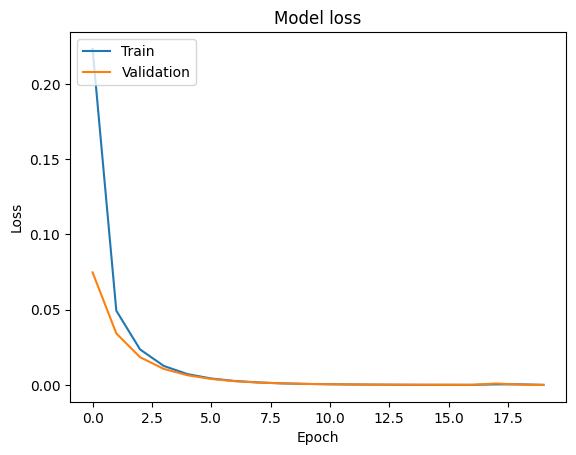

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [25]:
bestModel = keras.models.load_model(mdkCkhPointfilepath, custom_objects={'contrastive_loss_internal': get_contrastive_loss(margin=1.0)})  # Pass custom_objects during loading
bestModel.evaluate(test_ds)

43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 408ms/step - loss: 3.5251e-05


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 310ms/step - loss: 3.5251e-05


3.6976900446461514e-05

In [17]:
# Finding out at which threshold, the accuracy is maximum
def compute_accuracy_thresh(predictions, labels):
    """
    Computes the accuracy and threshold for a given set of predictions and labels.

    Args:
        predictions: A list of NumPy arrays, each containing predictions for a batch of images.
        labels: A list of NumPy arrays, each containing labels for a batch of images.

    Returns:
        max_acc: The maximum accuracy achieved across different thresholds.
        best_thresh: The threshold corresponding to the maximum accuracy.
    """
    # Concatenate predictions and labelzs into single arrays
    predictions = np.concatenate(predictions)
    labels = np.concatenate(labels)

    dmax = np.max(predictions)
    dmin = np.min(predictions)
    nsame = np.sum(labels == 1)
    ndiff = np.sum(labels == 0)

    step = 0.01
    max_acc = 0
    best_thresh = -1
    best_labels = None

    for d in np.arange(dmin, dmax + step, step):
        best_labels = (predictions <= d).astype(int)

        # Calculate tp, tn, fp, fn using best_labels and ground truth labels
        tp = np.sum((best_labels == 1) & (labels == 1))
        tn = np.sum((best_labels == 0) & (labels == 0))
        fp = np.sum((best_labels == 1) & (labels == 0))
        fn = np.sum((best_labels == 0) & (labels == 1))
        accuracy = (tp + tn) / (tp + tn + fp + fn)

        if accuracy > max_acc:
            max_acc = accuracy
            best_thresh = d

    return max_acc, best_thresh

def calculate_accuracy(predictions, labels, threshold):
    """
    Calculates the accuracy of predictions based on a given threshold.
    """
    # Flatten predictions to a 1D array
    predictions = np.concatenate(predictions).ravel()

    # Flatten labels to a 1D array
    labels = np.concatenate(labels).ravel()

    predictions = (predictions <= threshold).astype(int)
    accuracy = np.mean(predictions == labels)
    return accuracy

In [15]:
# Train predictions
pred_train = []

# Train y
tr_y_train = []

# Iterate through the dataset using `iter` and `next` until exhausted
for img_pair, label in iter(train_ds):
    tr_y_train.append(label.numpy().reshape(-1, 1))  # Convert label to numpy array before reshape
    pred_train.append(contractiveLossModel.predict([img_pair]))

# Train accuracy, threshold
tr_acc, threshold = compute_accuracy_thresh(pred_train,tr_y_train)
tr_acc, threshold

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_380', 'keras_tensor_381']
Received: inputs=(('Tensor(shape=(32, 224, 224, 3))', 'Tensor(shape=(32, 224, 224, 3))'),)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_380', 'keras_tensor_381']
Received: inputs=(('Tensor(shape=(None, 224, 224, 3))', 'Tensor(shape=(None, 224, 224, 3))'),)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


(1.0, 0.04391494017094374)

In [20]:
# Train predictions
pred_test = []

# Train y
tr_y_test = []

# Iterate through the dataset using `iter` and `next` until exhausted
for img_pair, label in iter(test_ds):
    tr_y_test.append(label.numpy().reshape(-1, 1))  # Convert label to numpy array before reshape
    pred_test.append(contractiveLossModel.predict([img_pair]))

# Train accuracy, threshold
tr_acc = calculate_accuracy(pred_train,tr_y_train, threshold)
tr_acc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

1.0

In [23]:
def visualize_batch(dataset, num_examples=3):
    # Get a batch from the dataset
    for (img1_batch, img2_batch), labels_batch in dataset.take(2):
        plt.figure(figsize=(15, 3*min(num_examples, len(labels_batch))))

        for i in range(min(num_examples, len(labels_batch))):
            img1 = img1_batch[i].numpy()
            img2 = img2_batch[i].numpy()
            label = labels_batch[i].numpy()
            predictedLabel = contractiveLossModel.predict([img1_batch[i:i+1], img2_batch[i:i+1]])

            plt.subplot(min(num_examples, len(labels_batch)), 2, i*2 + 1)
            plt.imshow(img1)
            plt.title(f"Image 1")
            plt.axis('off')

            plt.subplot(min(num_examples, len(labels_batch)), 2, i*2 + 2)
            plt.imshow(img2)
            plt.title(f"Image 2 (Similar: {bool(label)}, {float(predictedLabel)})")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


<ipython-input-23-8a8e7a150997>:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Image 2 (Similar: {bool(label)}, {float(predictedLabel)})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


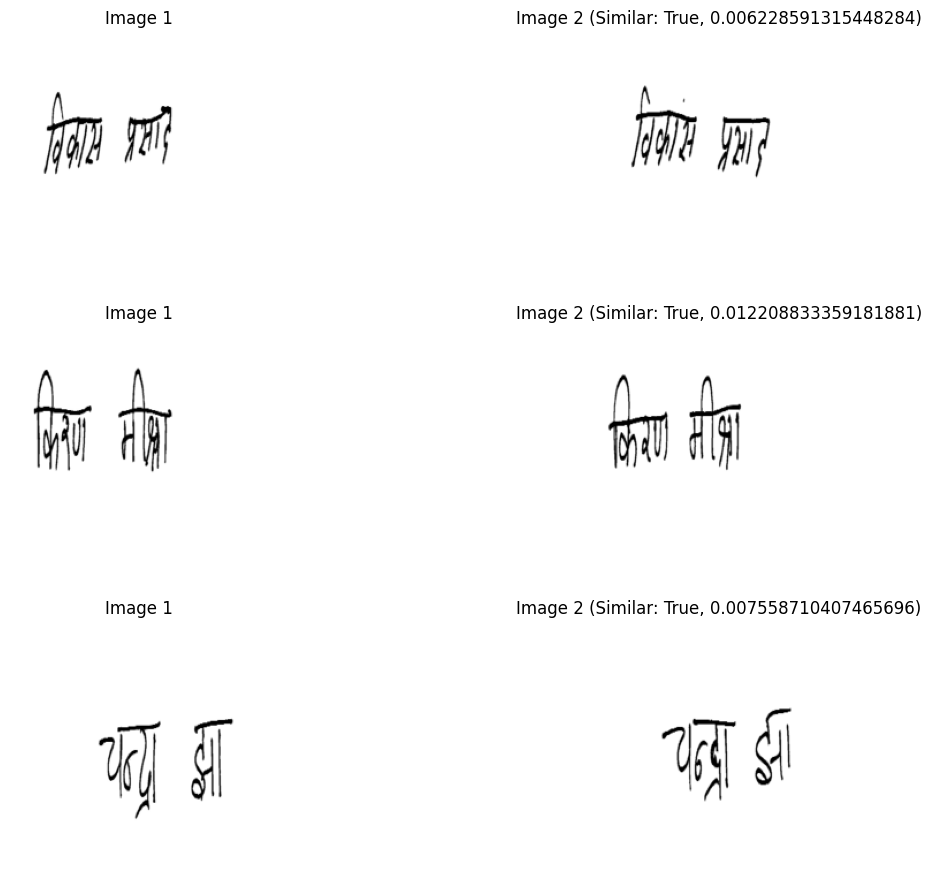

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


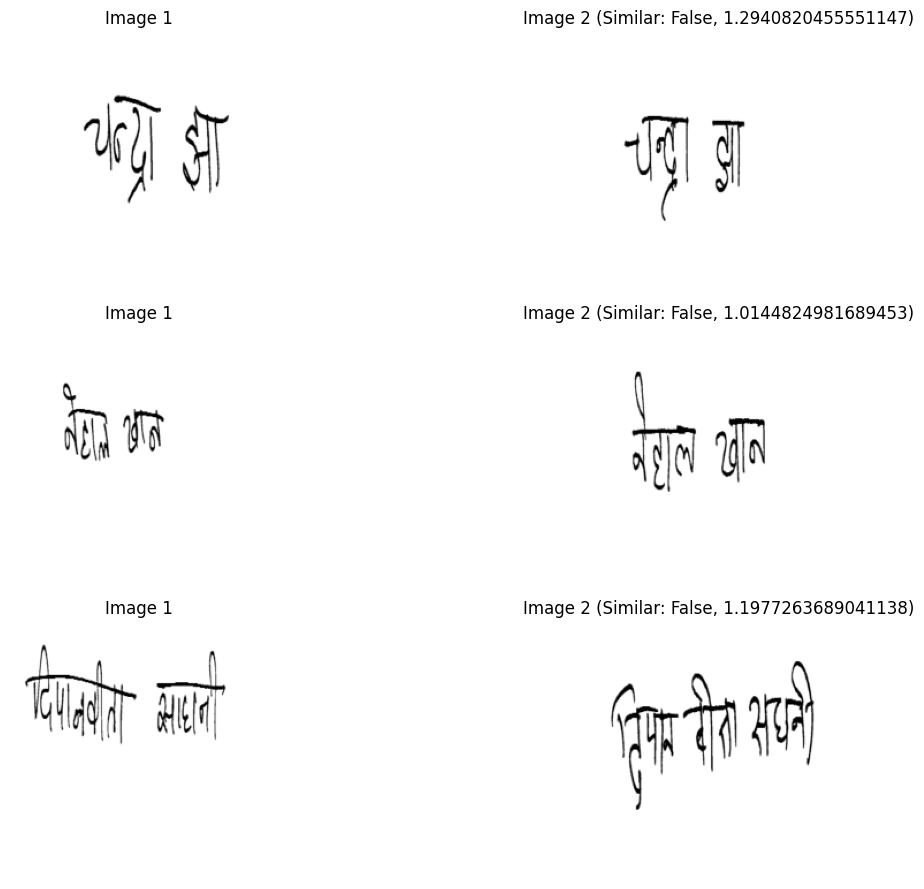

In [24]:
visualize_batch(dataset=test_ds, num_examples=3)